In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']    = (12, 6)
plt.rcParams['font.family']       = 'sans-serif'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

COLORS = {
    'primary'  : '#2C3E50',
    'profit'   : '#27AE60',
    'revenue'  : '#2980B9',
    'cost'     : '#E74C3C',
    'warning'  : '#F39C12',
    'highlight': '#8E44AD'
}

FACTORY_COLORS = {
    "Lot's O' Nuts"    : '#27AE60',
    "Wicked Choccy's"  : '#2980B9',
    "Sugar Shack"      : '#F39C12',
    "Secret Factory"   : '#8E44AD',
    "The Other Factory": '#E74C3C'
}

In [2]:
df = pd.read_csv('../data/nassau_candy_enriched.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

total_revenue      = df['Sales'].sum()
total_profit       = df['Gross Profit'].sum()
company_avg_margin = (total_profit / total_revenue * 100)

print(f"Data loaded: {df.shape[0]} rows")
print(f"Company Avg Margin: {company_avg_margin:.2f}%")

Data loaded: 6013 rows
Company Avg Margin: 65.96%


### Prepare Factory Summary

In [3]:
factory_summary = df.groupby('Factory').agg(
    Total_Revenue       = ('Sales', 'sum'),
    Total_Profit        = ('Gross Profit', 'sum'),
    Total_Cost          = ('Cost', 'sum'),
    Total_Units         = ('Units', 'sum'),
    Avg_Margin          = ('Gross_Margin_%', 'mean'),
    Avg_Profit_per_Unit = ('Profit_per_Unit', 'mean'),
    Avg_Cost_per_Unit   = ('Cost_per_Unit', 'mean'),
    Num_Products        = ('Product Name', 'nunique')
).round(2).reset_index()

factory_summary['Revenue_Share_%'] = (
    factory_summary['Total_Revenue'] / total_revenue * 100
).round(2)

factory_summary['Profit_Share_%'] = (
    factory_summary['Total_Profit'] / total_profit * 100
).round(2)

factory_summary['Margin_vs_Company'] = (
    factory_summary['Avg_Margin'] - company_avg_margin
).round(2)

factory_summary = factory_summary.sort_values('Avg_Margin', ascending=False).reset_index(drop=True)

print(factory_summary[['Factory', 'Avg_Margin', 'Margin_vs_Company',
                        'Total_Revenue', 'Total_Profit']].to_string(index=False))

          Factory  Avg_Margin  Margin_vs_Company  Total_Revenue  Total_Profit
    Lot's O' Nuts       69.20               3.24       45394.09      31393.09
  Wicked Choccy's       65.12              -0.84       32179.25      20960.19
      Sugar Shack       52.09             -13.87         141.34         76.14
   Secret Factory       51.71             -14.25        5418.75       2754.95
The Other Factory       12.88             -53.08         694.00        107.00


### Chart 20: Factory Avg Margin vs Company Average

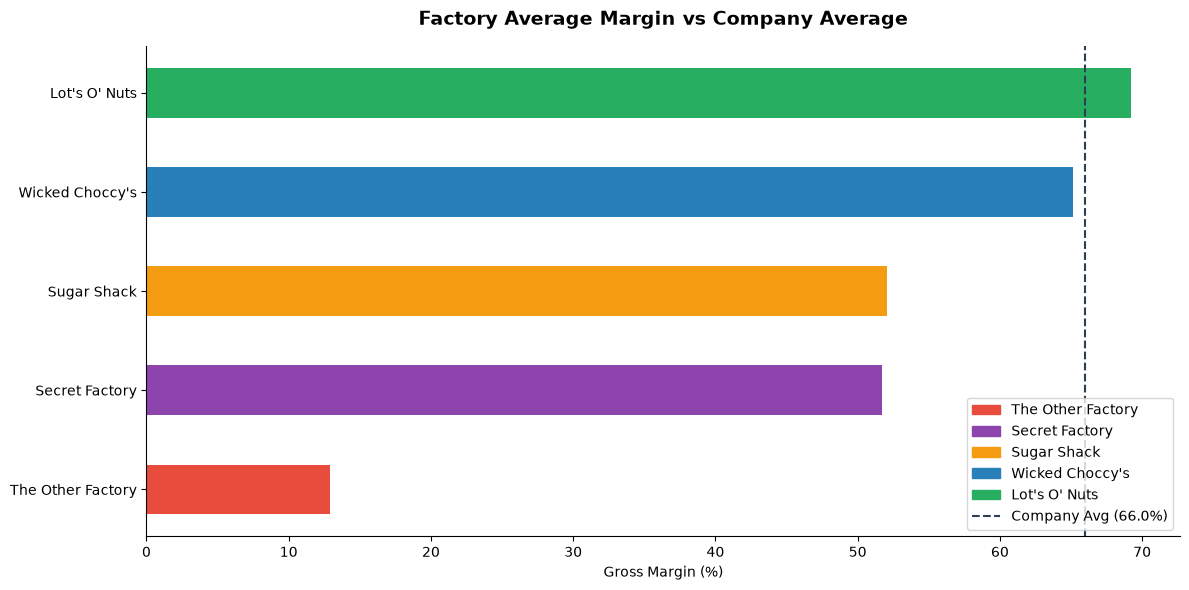

Chart 20 saved


In [4]:
sorted_factory = factory_summary.sort_values('Avg_Margin', ascending=True)
colors = [FACTORY_COLORS[f] for f in sorted_factory['Factory']]

fig, ax = plt.subplots()

ax.barh(sorted_factory['Factory'], sorted_factory['Avg_Margin'],
        color=colors, height=0.5)

ax.axvline(x=company_avg_margin, color=COLORS['primary'],
           linestyle='--', linewidth=1.5)

ax.set_title('Factory Average Margin vs Company Average',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Gross Margin (%)')
ax.set_ylabel('')

ax.legend(handles=[
    plt.Rectangle((0,0), 1, 1, color=FACTORY_COLORS[f], label=f)
    for f in sorted_factory['Factory']
] + [
    plt.Line2D([0], [0], color=COLORS['primary'], linestyle='--',
               label=f'Company Avg ({company_avg_margin:.1f}%)')
], loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/charts/20_factory_margin_vs_company_avg.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 20 saved")

### Chart 21: Factory Revenue vs Profit

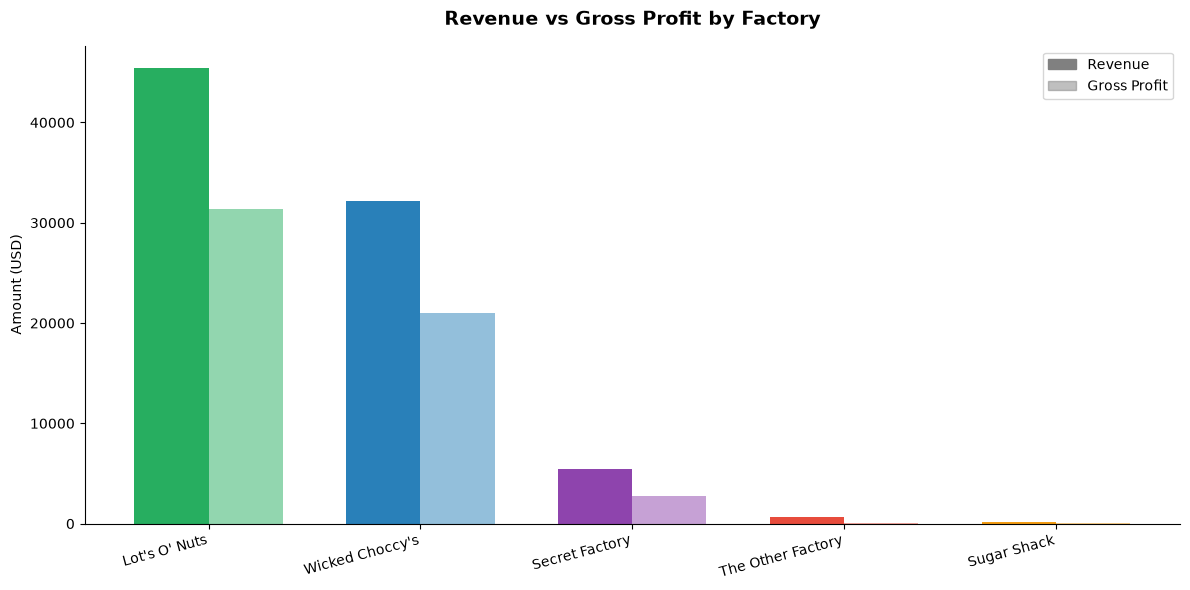

Chart 21 saved


In [5]:
sorted_factory = factory_summary.sort_values('Total_Revenue', ascending=False)

x     = np.arange(len(sorted_factory))
width = 0.35

fig, ax = plt.subplots()

ax.bar(x - width/2, sorted_factory['Total_Revenue'], width,
       color=[FACTORY_COLORS[f] for f in sorted_factory['Factory']],
       label='Revenue', alpha=1.0)

ax.bar(x + width/2, sorted_factory['Total_Profit'], width,
       color=[FACTORY_COLORS[f] for f in sorted_factory['Factory']],
       label='Gross Profit', alpha=0.5)

ax.set_title('Revenue vs Gross Profit by Factory',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Amount (USD)')
ax.set_xticks(x)
ax.set_xticklabels(sorted_factory['Factory'], rotation=15, ha='right')

ax.legend(handles=[
    plt.Rectangle((0,0), 1, 1, color='grey', alpha=1.0, label='Revenue'),
    plt.Rectangle((0,0), 1, 1, color='grey', alpha=0.5, label='Gross Profit')
], loc='upper right')

plt.tight_layout()
plt.savefig('../outputs/charts/21_factory_revenue_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 21 saved")

### Prepare Product × Factory Margin Data

In [6]:
product_factory = df.groupby(['Product Name', 'Factory']).agg(
    Avg_Margin    = ('Gross_Margin_%', 'mean'),
    Total_Revenue = ('Sales', 'sum'),
    Total_Profit  = ('Gross Profit', 'sum')
).round(2).reset_index()

# Shorten product names
def shorten(name):
    return name.replace('Wonka Bar - ', 'WB - ').replace('Wonka Bar -', 'WB -')

product_factory['Short_Name'] = product_factory['Product Name'].apply(shorten)
product_factory = product_factory.sort_values('Avg_Margin', ascending=True)

print(product_factory[['Short_Name', 'Factory', 'Avg_Margin']].to_string(index=False))

                Short_Name           Factory  Avg_Margin
                 Kazookles The Other Factory        7.69
                   Fun Dip       Sugar Shack       40.00
                     Nerds       Sugar Shack       46.67
                 SweeTARTS       Sugar Shack       46.67
        Lickable Wallpaper    Secret Factory       50.00
                 Wonka Gum    Secret Factory       52.00
      Fizzy Lifting Drinks       Sugar Shack       60.00
               Laffy Taffy       Sugar Shack       62.31
       WB - Milk Chocolate   Wicked Choccy's       64.92
WB - Triple Dazzle Caramel   Wicked Choccy's       65.33
        WB - Fudge Mallows     Lot's O' Nuts       66.67
   WB -Scrumdiddlyumptious     Lot's O' Nuts       69.44
WB - Nutty Crunch Surprise     Lot's O' Nuts       71.35
               Hair Toffee The Other Factory       77.78
    Everlasting Gobstopper    Secret Factory       80.00


### Chart 22: Product Margin Grouped by Factory

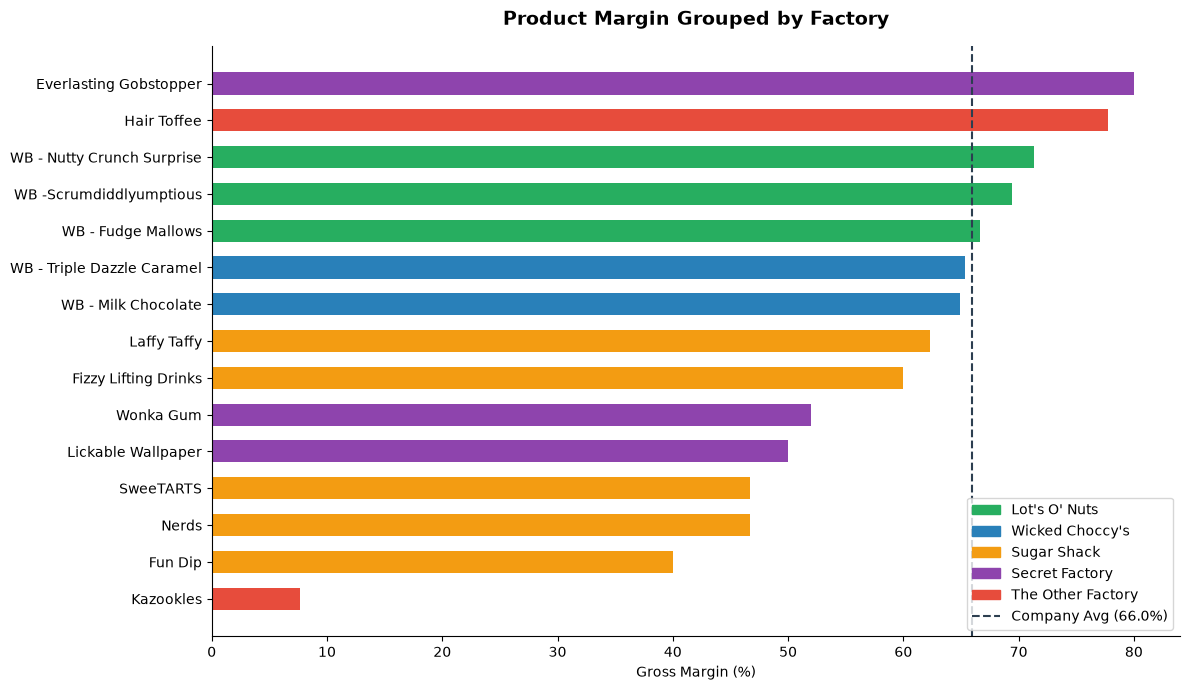

Chart 22 saved


In [7]:
colors = [FACTORY_COLORS[f] for f in product_factory['Factory']]

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(product_factory['Short_Name'], product_factory['Avg_Margin'],
        color=colors, height=0.6)

ax.axvline(x=company_avg_margin, color=COLORS['primary'],
           linestyle='--', linewidth=1.5)

ax.set_title('Product Margin Grouped by Factory',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Gross Margin (%)')
ax.set_ylabel('')

ax.legend(handles=[
    plt.Rectangle((0,0), 1, 1, color=FACTORY_COLORS[f], label=f)
    for f in FACTORY_COLORS
] + [
    plt.Line2D([0], [0], color=COLORS['primary'], linestyle='--',
               label=f'Company Avg ({company_avg_margin:.1f}%)')
], loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/charts/22_product_margin_by_factory.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 22 saved")

### Chart 23: Factory Cost per Unit vs Profit per Unit

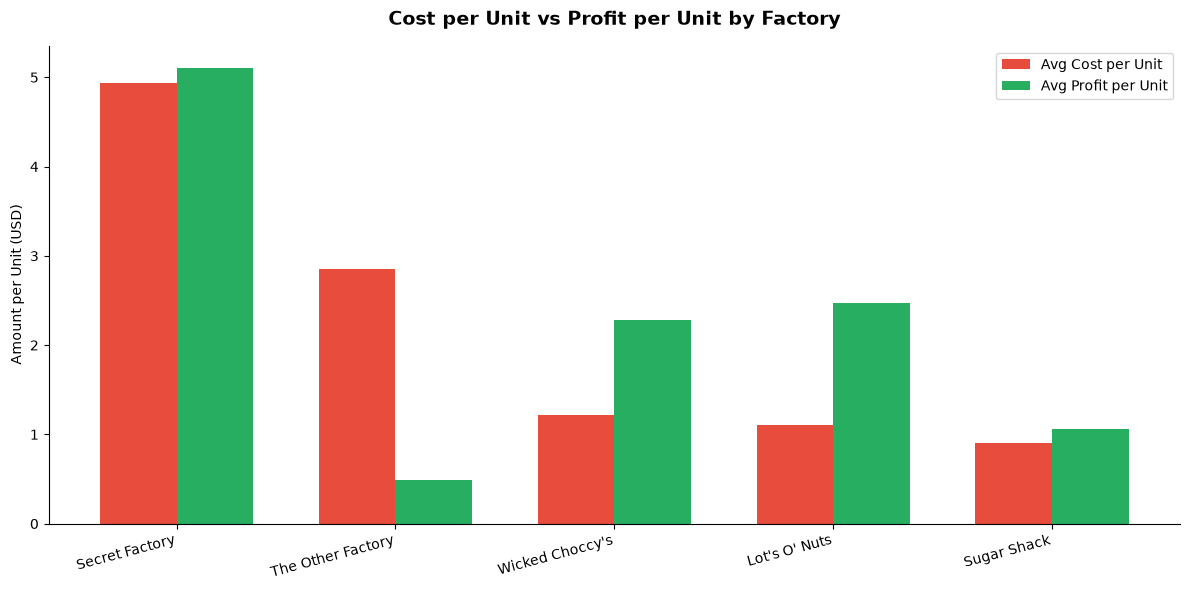

Chart 23 saved


In [8]:
sorted_factory = factory_summary.sort_values('Avg_Cost_per_Unit', ascending=False)

x     = np.arange(len(sorted_factory))
width = 0.35

fig, ax = plt.subplots()

ax.bar(x - width/2, sorted_factory['Avg_Cost_per_Unit'], width,
       color=COLORS['cost'],   label='Avg Cost per Unit')

ax.bar(x + width/2, sorted_factory['Avg_Profit_per_Unit'], width,
       color=COLORS['profit'], label='Avg Profit per Unit')

ax.set_title('Cost per Unit vs Profit per Unit by Factory',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Amount per Unit (USD)')
ax.set_xticks(x)
ax.set_xticklabels(sorted_factory['Factory'], rotation=15, ha='right')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('../outputs/charts/23_factory_cost_vs_profit_per_unit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 23 saved")

### Prepare Factory Heatmap Data

In [9]:
# Factory x Division profit heatmap
factory_div = df.groupby(['Factory', 'Division'])['Gross Profit']\
                .sum().reset_index()

heatmap_pivot = factory_div.pivot(
    index='Factory',
    columns='Division',
    values='Gross Profit'
).fillna(0).round(2)

# Sort by total profit
heatmap_pivot['Total'] = heatmap_pivot.sum(axis=1)
heatmap_pivot = heatmap_pivot.sort_values('Total', ascending=False)
heatmap_pivot = heatmap_pivot.drop(columns='Total')

print(heatmap_pivot)

Division           Chocolate    Other   Sugar
Factory                                      
Lot's O' Nuts       31393.09     0.00    0.00
Wicked Choccy's     20960.19     0.00    0.00
Secret Factory          0.00  2650.95  104.00
The Other Factory       0.00    47.50   59.50
Sugar Shack             0.00     0.00   76.14


### Chart 24: Factory × Division Profit Heatmap

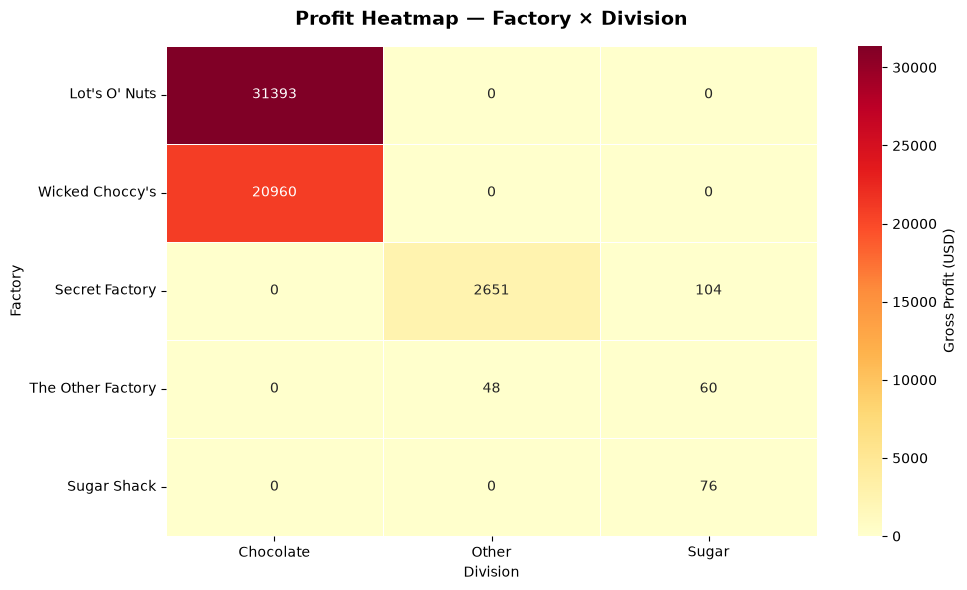

Chart 24 saved


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    heatmap_pivot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Gross Profit (USD)'},
    ax=ax
)

ax.set_title('Profit Heatmap — Factory × Division',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Division')
ax.set_ylabel('Factory')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/charts/24_factory_division_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 24 saved")